# Notebook 7: Market Anomaly Detection
### NIFTY-50 Investment Intelligence — Optional Task C
Detects three types of market anomalies:
- **Volatility spikes** — sudden increase in daily volatility
- **Extreme drawdowns** — sharp price falls below historical norms
- **Unusual trading activity** — abnormal volume surges

In [9]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

from src.data_loader import load_stock, get_symbol_list, get_sector_map, get_close_price_matrix
from src.indicators import add_all_indicators

os.makedirs('../report', exist_ok=True)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
print("Imports OK")

Imports OK


## 1. Anomaly Detection Methods

In [10]:
def detect_volatility_spikes(df: pd.DataFrame, window: int = 21,
                                threshold_sigma: float = 2.5) -> pd.DataFrame:
    """
    Flag days where realised volatility is >threshold_sigma standard
    deviations above its rolling mean. Uses z-score on rolling vol.
    """
    df = df.copy()
    ret = df['Close'].pct_change()
    df['RollingVol'] = ret.rolling(window).std() * np.sqrt(252) * 100
    roll_mean = df['RollingVol'].rolling(window * 3).mean()
    roll_std  = df['RollingVol'].rolling(window * 3).std()
    df['Vol_Zscore'] = (df['RollingVol'] - roll_mean) / roll_std
    df['VolSpike'] = (df['Vol_Zscore'] > threshold_sigma).astype(int)
    return df

def detect_extreme_drawdowns(df: pd.DataFrame, threshold_pct: float = -5.0) -> pd.DataFrame:
    """Flag single-day returns below threshold (extreme negative moves)."""
    df = df.copy()
    df['DailyReturn'] = df['Close'].pct_change() * 100
    df['ExtremeDrawdown'] = (df['DailyReturn'] < threshold_pct).astype(int)
    # Also flag sustained drawdown periods
    roll_max = df['Close'].cummax()
    df['Drawdown_pct'] = (df['Close'] - roll_max) / roll_max * 100
    df['DeepDrawdown'] = (df['Drawdown_pct'] < -20).astype(int)
    return df

def detect_volume_anomalies(df: pd.DataFrame, window: int = 20,
                             threshold_sigma: float = 2.5) -> pd.DataFrame:
    """Flag days where volume is unusually high vs rolling baseline."""
    df = df.copy()
    df['VolumeSMA'] = df['Volume'].rolling(window).mean()
    df['VolumeStd'] = df['Volume'].rolling(window).std()
    df['Volume_Zscore'] = (df['Volume'] - df['VolumeSMA']) / df['VolumeStd'].replace(0, np.nan)
    df['VolumeSpike'] = (df['Volume_Zscore'] > threshold_sigma).astype(int)
    return df

def detect_all_anomalies(df: pd.DataFrame) -> pd.DataFrame:
    """Apply all three detectors and combine into one DataFrame."""
    df = detect_volatility_spikes(df)
    df = detect_extreme_drawdowns(df)
    df = detect_volume_anomalies(df)
    df['AnyAnomaly'] = ((df['VolSpike'] == 1) |
                         (df['ExtremeDrawdown'] == 1) |
                         (df['VolumeSpike'] == 1)).astype(int)
    return df

print("Anomaly detection functions defined.")

Anomaly detection functions defined.


## 2. Isolation Forest — Multivariate Anomaly Detection

In [11]:
def isolation_forest_anomalies(df: pd.DataFrame,
                                contamination: float = 0.02) -> pd.DataFrame:
    """
    Multivariate anomaly detection using Isolation Forest.
    Treats each day as a point in feature space and flags
    the most isolated points as anomalies.
    contamination: expected fraction of anomalies (2% default).
    """
    df = df.copy()
    df = add_all_indicators(df)

    feature_cols = ['DailyReturn', 'Volume_Zscore', 'RollingVol',
                    'High_Low_Range', 'BB_Width', 'RSI', 'ATR']

    df['DailyReturn']  = df['Close'].pct_change() * 100
    df['VolumeSMA']    = df['Volume'].rolling(20).mean()
    df['VolumeStd']    = df['Volume'].rolling(20).std()
    df['Volume_Zscore'] = (df['Volume'] - df['VolumeSMA']) / df['VolumeStd'].replace(0, np.nan)
    df['RollingVol']   = df['DailyReturn'].rolling(21).std() * np.sqrt(252)

    feat = [c for c in feature_cols if c in df.columns]
    X = df[feat].dropna()

    sc = StandardScaler()
    X_sc = sc.fit_transform(X)

    iso = IsolationForest(contamination=contamination, random_state=42, n_estimators=200)
    preds = iso.fit_predict(X_sc)  # -1 = anomaly, 1 = normal
    scores = iso.score_samples(X_sc)

    df.loc[X.index, 'IF_Anomaly'] = (preds == -1).astype(int)
    df.loc[X.index, 'IF_Score']   = scores   # more negative = more anomalous
    df['IF_Anomaly'] = df['IF_Anomaly'].fillna(0)
    df['IF_Score']   = df['IF_Score'].fillna(0)
    return df

print("Isolation Forest function defined.")

Isolation Forest function defined.


## 3. Apply to RELIANCE — Visualise All Anomalies

In [12]:
sym = 'RELIANCE'
df = load_stock(sym)
df = detect_all_anomalies(df)
df_if = isolation_forest_anomalies(df.copy())

# Focus on 2018-2021 for clarity
mask = df['Date'] >= '2015-01-01'
df_plot = df[mask].copy()
df_if_plot = df_if[mask].copy()

print(f"Anomaly counts (2015-2021):")
print(f"  Volatility spikes:    {df_plot['VolSpike'].sum()}")
print(f"  Extreme daily drops:  {df_plot['ExtremeDrawdown'].sum()}")
print(f"  Volume spikes:        {df_plot['VolumeSpike'].sum()}")
print(f"  Any anomaly:          {df_plot['AnyAnomaly'].sum()}")
print(f"  Isolation Forest:     {df_if_plot['IF_Anomaly'].sum()}")

Anomaly counts (2015-2021):
  Volatility spikes:    70
  Extreme daily drops:  13
  Volume spikes:        50
  Any anomaly:          115
  Isolation Forest:     32.0


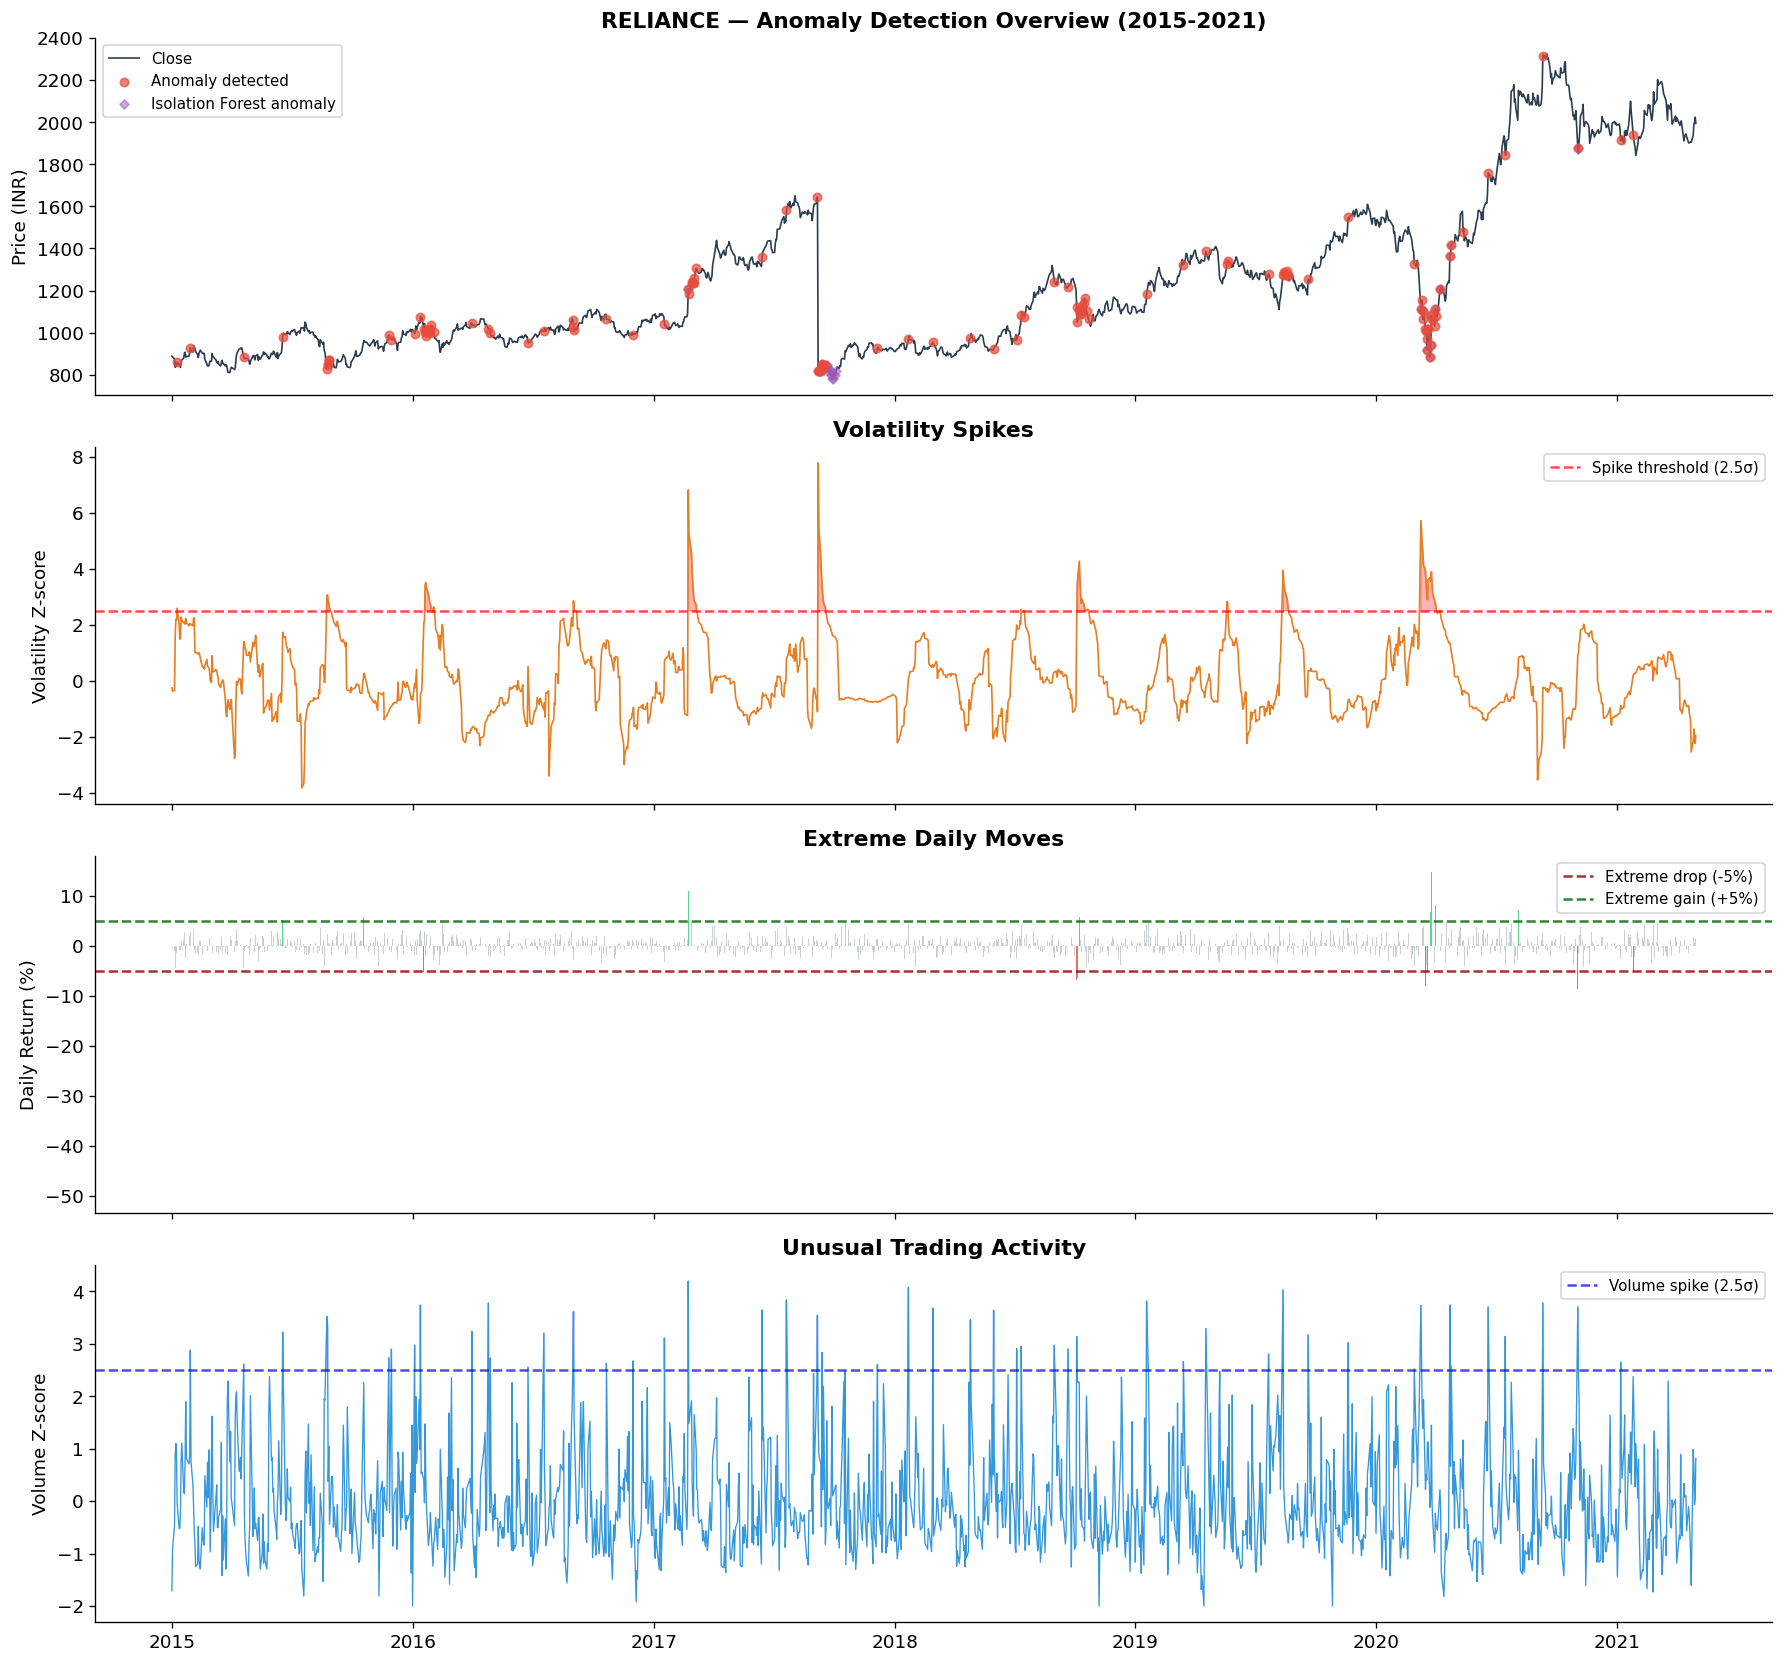

In [13]:
fig, axes = plt.subplots(4, 1, figsize=(15, 14), sharex=True)

# Price + anomaly markers
ax = axes[0]
ax.plot(df_plot['Date'], df_plot['Close'], color='#2c3e50', lw=1, label='Close')
any_anom = df_plot[df_plot['AnyAnomaly'] == 1]
ax.scatter(any_anom['Date'], any_anom['Close'],
           color='#e74c3c', s=25, zorder=5, label='Anomaly detected', alpha=0.7)
if_anom = df_if_plot[df_if_plot['IF_Anomaly'] == 1]
ax.scatter(if_anom['Date'], if_anom['Close'],
           color='#9b59b6', s=15, marker='D', zorder=4,
           label='Isolation Forest anomaly', alpha=0.5)
ax.set_ylabel("Price (INR)")
ax.set_title(f"{sym} — Anomaly Detection Overview (2015-2021)",
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)

# Volatility z-score
ax2 = axes[1]
ax2.plot(df_plot['Date'], df_plot['Vol_Zscore'], color='#e67e22', lw=1)
ax2.axhline(2.5, color='red', linestyle='--', alpha=0.7, label='Spike threshold (2.5σ)')
ax2.fill_between(df_plot['Date'], 2.5, df_plot['Vol_Zscore'],
                  where=(df_plot['Vol_Zscore'] > 2.5), alpha=0.3, color='red')
ax2.set_ylabel("Volatility Z-score")
ax2.set_title("Volatility Spikes", fontweight='bold')
ax2.legend(fontsize=9)

# Daily returns with extreme drops highlighted
ax3 = axes[2]
ax3.bar(df_plot['Date'], df_plot['DailyReturn'],
        color=df_plot['DailyReturn'].apply(lambda x: '#e74c3c' if x < -5 else '#2ecc71' if x > 5 else '#bdc3c7'),
        width=1, alpha=0.8)
ax3.axhline(-5, color='darkred', linestyle='--', alpha=0.8, label='Extreme drop (-5%)')
ax3.axhline(5,  color='darkgreen', linestyle='--', alpha=0.8, label='Extreme gain (+5%)')
ax3.set_ylabel("Daily Return (%)")
ax3.set_title("Extreme Daily Moves", fontweight='bold')
ax3.legend(fontsize=9)

# Volume Z-score
ax4 = axes[3]
ax4.plot(df_plot['Date'], df_plot['Volume_Zscore'].clip(-2, 10), color='#3498db', lw=0.8)
ax4.fill_between(df_plot['Date'], 2.5, df_plot['Volume_Zscore'].clip(-2, 10),
                  where=(df_plot['Volume_Zscore'] > 2.5), alpha=0.3, color='blue')
ax4.axhline(2.5, color='blue', linestyle='--', alpha=0.7, label='Volume spike (2.5σ)')
ax4.set_ylabel("Volume Z-score")
ax4.set_title("Unusual Trading Activity", fontweight='bold')
ax4.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../report/anomaly_detection.png', bbox_inches='tight')
plt.show()

## 4. Top Anomaly Events — Dated & Labelled

In [14]:
# Extract most significant anomaly events
df_full = load_stock(sym)
df_full = detect_all_anomalies(df_full)
df_full_if = isolation_forest_anomalies(df_full.copy())

# Merge IF score
df_full['IF_Score'] = df_full_if['IF_Score']
df_full['IF_Anomaly'] = df_full_if['IF_Anomaly']

# Most extreme volatility spikes
vol_spikes = df_full[df_full['VolSpike'] == 1].nlargest(10, 'Vol_Zscore')
print("Top 10 Volatility Spikes:")
print(vol_spikes[['Date','Close','DailyReturn','RollingVol','Vol_Zscore']].to_string(index=False))

print("\nTop 10 Extreme Daily Drops:")
extreme_drops = df_full[df_full['ExtremeDrawdown'] == 1].nsmallest(10, 'DailyReturn')
print(extreme_drops[['Date','Close','DailyReturn','Volume']].to_string(index=False))

print("\nTop 10 Volume Spikes:")
vol_spikes2 = df_full[df_full['VolumeSpike'] == 1].nlargest(10, 'Volume_Zscore')
print(vol_spikes2[['Date','Close','DailyReturn','Volume','Volume_Zscore']].to_string(index=False))

Top 10 Volatility Spikes:
      Date   Close  DailyReturn  RollingVol  Vol_Zscore
2017-09-07  818.10   -50.279567  175.588306    7.772305
2009-11-26 1063.75   -51.530961  184.707441    7.488853
2006-01-18  693.70   -25.288099   94.501512    7.154209
2002-10-31  265.50    13.267918   57.131978    7.066836
2017-02-22 1207.50    10.963058   39.447253    6.808790
2004-05-17  404.30   -15.258856   64.135597    6.174415
2020-03-09 1114.15   -12.340677   48.506174    5.713873
2017-09-08  816.90    -0.146681  175.678864    5.467155
2004-05-18  433.70     7.271828   70.923153    5.369323
2009-11-27 1045.95    -1.673325  184.104707    5.348675

Top 10 Extreme Daily Drops:
      Date   Close  DailyReturn   Volume
2009-11-26 1063.75   -51.530961  5079362
2017-09-07  818.10   -50.279567  7408536
2006-01-18  693.70   -25.288099 61000245
2008-10-24 1019.50   -16.273149  9257453
2004-05-17  404.30   -15.258856  9367243
2020-03-23  884.05   -13.153888 18593713
2008-11-05 1269.05   -12.575778 11704998
2

## 5. Universe-Wide Anomaly Heatmap

Processing all stocks (takes ~2 minutes)...


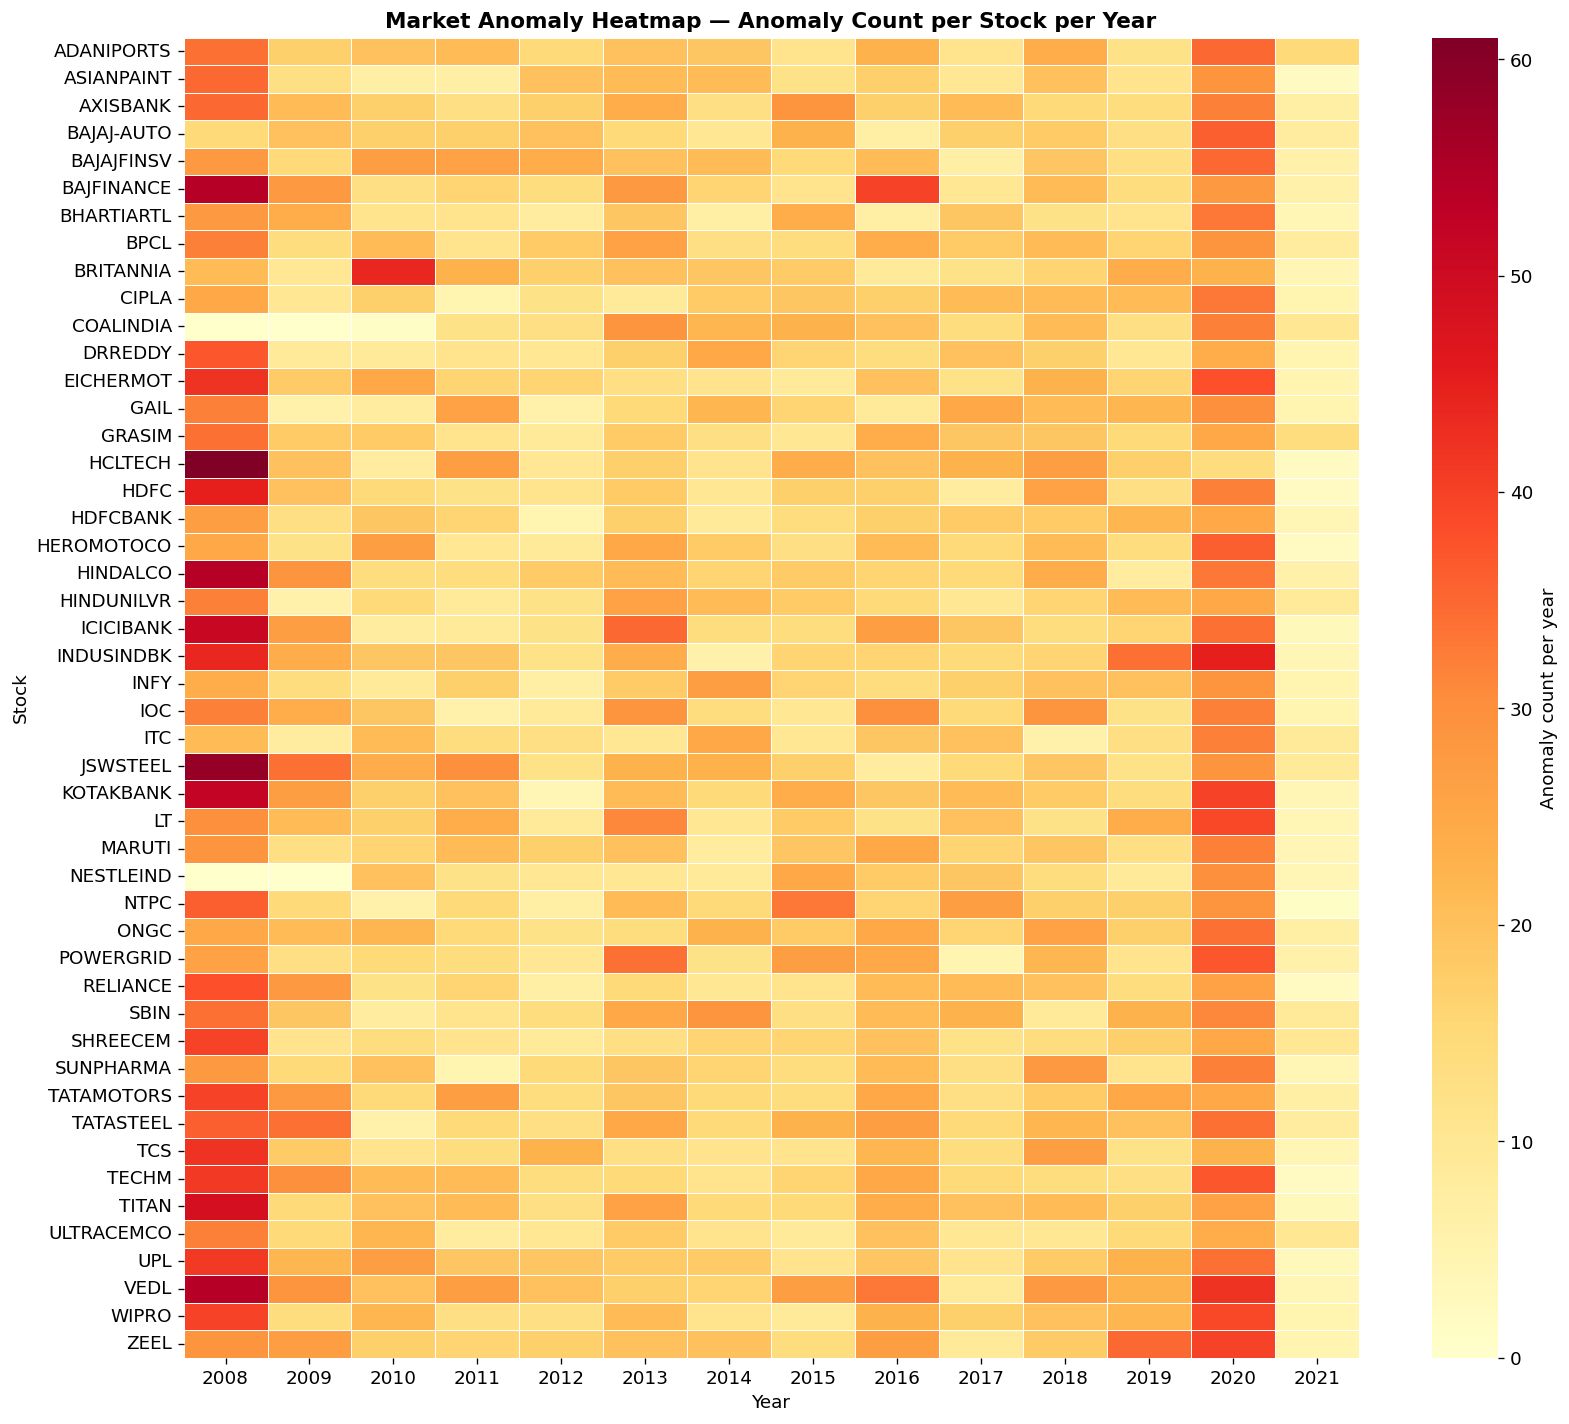


Most anomalous years (total across all stocks):
Year
2008    1668.0
2020    1507.0
2013     972.0
2016     957.0
2018     919.0
2009     869.0
2015     804.0
2019     802.0
2010     801.0
2011     754.0
2017     752.0
2014     750.0
2012     619.0
2021     270.0


In [15]:
# Count anomalies per stock per year — shows market-wide stress periods
symbols = get_symbol_list()
sector_map = get_sector_map()

anomaly_counts = {}
print("Processing all stocks (takes ~2 minutes)...")

for sym_i in symbols:
    try:
        df_i = load_stock(sym_i)
        df_i = detect_all_anomalies(df_i)
        df_i['Year'] = df_i['Date'].dt.year
        counts = df_i[df_i['AnyAnomaly'] == 1].groupby('Year').size()
        anomaly_counts[sym_i] = counts
    except: pass

anom_df = pd.DataFrame(anomaly_counts).T
anom_df = anom_df.fillna(0)
# Focus on 2008-2021
year_cols = [c for c in anom_df.columns if 2008 <= c <= 2021]
anom_df = anom_df[year_cols]

import seaborn as sns
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(anom_df, cmap='YlOrRd', ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Anomaly count per year'})
ax.set_title("Market Anomaly Heatmap — Anomaly Count per Stock per Year",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Year"); ax.set_ylabel("Stock")
plt.tight_layout()
plt.savefig('../report/anomaly_heatmap.png', bbox_inches='tight')
plt.show()

# Years with most anomalies across universe
print("\nMost anomalous years (total across all stocks):")
print(anom_df.sum().sort_values(ascending=False).to_string())

## 6. Anomaly Detection Summary

In [16]:
sym = 'RELIANCE'
df = load_stock(sym)
df = detect_all_anomalies(df)

total_days = len(df)
anom_days  = df['AnyAnomaly'].sum()

print("=" * 55)
print("ANOMALY DETECTION SUMMARY")
print("=" * 55)
print(f"\nStock: {sym}  |  Total trading days: {total_days}")
print(f"Anomaly rate: {anom_days/total_days*100:.2f}% of all days ({anom_days} days)")

print(f"\nDetection methods:")
print(f"  1. Volatility spike (z-score > 2.5σ): {df['VolSpike'].sum()} events")
print(f"  2. Extreme daily drop (< -5%):         {df['ExtremeDrawdown'].sum()} events")
print(f"  3. Volume spike (z-score > 2.5σ):      {df['VolumeSpike'].sum()} events")

# Coincidence with known events
print(f"\nKey market events confirmed by anomaly detection:")
for yr, event in [(2008,'Global Financial Crisis'), (2011,'Euro Debt Crisis'),
                   (2015,'China Slowdown'), (2020,'COVID-19 Crash')]:
    yr_anom = df[df['Date'].dt.year == yr]['AnyAnomaly'].sum()
    yr_days = df[df['Date'].dt.year == yr].shape[0]
    print(f"  {yr} ({event}): {yr_anom}/{yr_days} anomaly days ({yr_anom/yr_days*100:.1f}%)")

print(f"\nIsolation Forest provides unsupervised multivariate detection,")
print(f"capturing anomalies that statistical thresholds alone might miss.")

ANOMALY DETECTION SUMMARY

Stock: RELIANCE  |  Total trading days: 5306
Anomaly rate: 7.09% of all days (376 days)

Detection methods:
  1. Volatility spike (z-score > 2.5σ): 179 events
  2. Extreme daily drop (< -5%):         79 events
  3. Volume spike (z-score > 2.5σ):      155 events

Key market events confirmed by anomaly detection:
  2008 (Global Financial Crisis): 38/246 anomaly days (15.4%)
  2011 (Euro Debt Crisis): 16/247 anomaly days (6.5%)
  2015 (China Slowdown): 11/248 anomaly days (4.4%)
  2020 (COVID-19 Crash): 26/252 anomaly days (10.3%)

Isolation Forest provides unsupervised multivariate detection,
capturing anomalies that statistical thresholds alone might miss.
